<a href="https://colab.research.google.com/github/skmarieta/blood-cell-counter/blob/main/research_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Подготовка окружения


## 1.1 Подключение диска

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = '/content/drive/MyDrive/blood_cell_counter/data/archive.zip'

In [ ]:
import zipfile

# Куда распакуем — создадим папку dataset рядом с нашим рабочим местом
extract_path = '/content/drive/MyDrive/blood_cell_counter/dataset'

# Открываем архив и извлекаем всё содержимое
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Архив распакован!")

In [ ]:
# Смотрим структуру папок — что появилось после распаковки
for root, dirs, files in os.walk(extract_path):
    # Считаем глубину вложенности для красивого отступа
    level = root.replace(extract_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")

    # Показываем файлы, но не больше 5 штук на папку — чтобы не засорять вывод
    subindent = '  ' * (level + 1)
    for i, file in enumerate(files[:5]):
        print(f"{subindent}📄 {file}")
    if len(files) > 5:
        print(f"{subindent}... и ещё {len(files) - 5} файлов")

📁 dataset/
  📁 archive/
    📄 LICENSE.md
    📄 README.md
    📄 meta.json
    📁 test/
      📁 ann/
        📄 BloodImage_00320.jpeg.json
        📄 BloodImage_00178.jpeg.json
        📄 BloodImage_00208.jpeg.json
        📄 BloodImage_00065.jpeg.json
        📄 BloodImage_00253.jpeg.json
        ... и ещё 67 файлов
      📁 img/
        📄 BloodImage_00019.jpeg
        📄 BloodImage_00234.jpeg
        📄 BloodImage_00058.jpeg
        📄 BloodImage_00074.jpeg
        📄 BloodImage_00062.jpeg
        ... и ещё 67 файлов
    📁 train/
      📁 ann/
        📄 BloodImage_00393.jpeg.json
        📄 BloodImage_00050.jpeg.json
        📄 BloodImage_00266.jpeg.json
        📄 BloodImage_00044.jpeg.json
        📄 BloodImage_00387.jpeg.json
        ... и ещё 200 файлов
      📁 img/
        📄 BloodImage_00275.jpeg
        📄 BloodImage_00388.jpeg
        📄 BloodImage_00371.jpeg
        📄 BloodImage_00408.jpeg
        📄 BloodImage_00263.jpeg
        ... и ещё 200 файлов
    📁 val/
      📁 ann/
        📄 BloodImage_0

## 1.2 Установка библиотек


In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.7 MB/s eta 0:00:00


# 2. Подготовка данных

## 2.1 Конвертация аннотаций


In [ ]:
import json
import os

# Словарь: имя класса → номер для YOLO
CLASS_MAP = {
    'RBC': 0,
    'WBC': 1,
    'Platelets': 2
}

# Базовый путь к датасету
base_path = '/content/drive/MyDrive/blood_cell_counter/dataset/archive'

# Обрабатываем все три сплита: train, val, test
for split in ['train', 'val', 'test']:
    ann_dir = os.path.join(base_path, split, 'ann')  # папка с JSON
    img_dir = os.path.join(base_path, split, 'img')  # папка с картинками

    # Папка для YOLO-аннотаций — создаём рядом с img
    labels_dir = os.path.join(base_path, split, 'labels')
    os.makedirs(labels_dir, exist_ok=True)  # exist_ok — не ругаться если уже есть

    json_files = [f for f in os.listdir(ann_dir) if f.endswith('.json')]

    for json_file in json_files:
        # Читаем JSON
        with open(os.path.join(ann_dir, json_file), 'r') as f:
            data = json.load(f)

        img_w = data['size']['width']   # ширина картинки
        img_h = data['size']['height']  # высота картинки

        lines = []  # сюда будем собирать строки для .txt файла

        for obj in data['objects']:
            class_title = obj['classTitle']

            # Пропускаем объект если его класс нам незнаком
            if class_title not in CLASS_MAP:
                continue

            class_id = CLASS_MAP[class_title]

            # Координаты двух углов прямоугольника
            x1, y1 = obj['points']['exterior'][0]  # левый верхний угол
            x2, y2 = obj['points']['exterior'][1]  # правый нижний угол

            # Считаем центр и размеры, нормируем на размер картинки
            cx = (x1 + x2) / 2 / img_w
            cy = (y1 + y2) / 2 / img_h
            w  = (x2 - x1) / img_w
            h  = (y2 - y1) / img_h

            lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        # Имя .txt файла = имя картинки без расширения
        # BloodImage_00393.jpeg.json → BloodImage_00393.txt
        txt_name = json_file.replace('.jpeg.json', '.txt')
        txt_path = os.path.join(labels_dir, txt_name)

        with open(txt_path, 'w') as f:
            f.write('\n'.join(lines))

    print(f"✅ {split}: обработано {len(json_files)} файлов → папка labels/")

print("\n🎉 Конвертация завершена!")

✅ train: обработано 205 файлов → папка labels/
✅ val: обработано 87 файлов → папка labels/
✅ test: обработано 72 файлов → папка labels/

🎉 Конвертация завершена!


## 2.2 Визуальная проверка


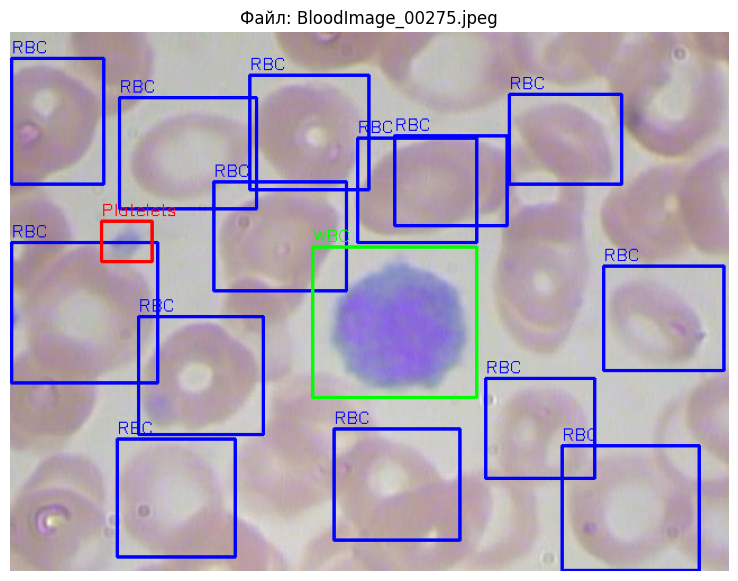


Размер картинки: 640×480
Аннотация: /content/drive/MyDrive/blood_cell_counter/dataset/archive/train/labels/BloodImage_00275.txt


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Цвета для каждого класса (в формате BGR — так работает OpenCV)
COLORS = {
    0: (255, 0, 0),    # RBC — синий
    1: (0, 255, 0),    # WBC — зелёный
    2: (0, 0, 255),    # Platelets — красный
}
CLASS_NAMES = {0: 'RBC', 1: 'WBC', 2: 'Platelets'}

# Берём первую картинку из train
img_dir    = '/content/drive/MyDrive/blood_cell_counter/dataset/archive/train/img'
labels_dir = '/content/drive/MyDrive/blood_cell_counter/dataset/archive/train/labels'

# Первый файл из папки
img_name   = [f for f in os.listdir(img_dir) if f.endswith('.jpeg')][0]
label_name = img_name.replace('.jpeg', '.txt')

img_path   = os.path.join(img_dir, img_name)
label_path = os.path.join(labels_dir, label_name)

# Читаем картинку
img = cv2.imread(img_path)
img_h, img_w = img.shape[:2]  # shape возвращает (высота, ширина, каналы)

# Читаем аннотацию и рисуем каждую рамку
with open(label_path, 'r') as f:
    for line in f:
        class_id, cx, cy, w, h = map(float, line.strip().split())
        class_id = int(class_id)

        # Обратное преобразование: из долей обратно в пиксели
        x1 = int((cx - w / 2) * img_w)
        y1 = int((cy - h / 2) * img_h)
        x2 = int((cx + w / 2) * img_w)
        y2 = int((cy + h / 2) * img_h)

        color = COLORS[class_id]

        # Рисуем прямоугольник
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Подписываем класс
        cv2.putText(img, CLASS_NAMES[class_id],
                    (x1, y1 - 5),           # чуть выше рамки
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, color, 1)

# OpenCV хранит цвета в BGR, matplotlib ждёт RGB — меняем порядок каналов
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(img_rgb)
plt.title(f'Файл: {img_name}')
plt.axis('off')  # убираем оси с цифрами — они тут не нужны
plt.show()

print(f"\nРазмер картинки: {img_w}×{img_h}")
print(f"Аннотация: {label_path}")

In [ ]:
import yaml

# Всё содержимое конфига — обычный Python-словарь
config = {
    # Абсолютный путь к корню датасета
    'path': '/content/drive/MyDrive/blood_cell_counter/dataset/archive',

    # Пути к картинкам относительно path (не к labels — YOLO сам найдёт labels рядом)
    'train': 'train/img',
    'val':   'val/img',
    'test':  'test/img',

    # Количество классов
    'nc': 3,

    # Названия классов — порядок важен! Должен совпадать с CLASS_MAP из конвертации
    'names': ['RBC', 'WBC', 'Platelets']
}

# Путь куда сохраняем файл
yaml_path = '/content/drive/MyDrive/blood_cell_counter/data.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

print("✅ Файл data.yaml создан!")
print()
print("Содержимое:")
print("─" * 30)

# Читаем и печатаем обратно — чтобы убедиться что всё записалось правильно
with open(yaml_path, 'r') as f:
    print(f.read())

✅ Файл data.yaml создан!

Содержимое:
──────────────────────────────
names:
- RBC
- WBC
- Platelets
nc: 3
path: /content/drive/MyDrive/blood_cell_counter/dataset/archive
test: test/img
train: train/img
val: val/img



In [ ]:
from ultralytics import YOLO

# Загружаем предобученную модель YOLOv8 Nano
# Если файла нет локально — скачается автоматически (~6 МБ)
model = YOLO('yolov8n.pt')

# Запускаем обучение
results = model.train(
    data='/content/drive/MyDrive/blood_cell_counter/data.yaml',
    epochs=50,          # сколько раз модель пройдёт по всему датасету
    imgsz=640,          # размер картинки при обучении (640×640 — стандарт YOLO)
    batch=16,           # сколько картинок обрабатывается за один шаг
    patience=10,        # остановить если за 10 эпох нет улучшений
    device=0,           # 0 = использовать первый GPU (нашу Tesla T4)
    project='/content/drive/MyDrive/blood_cell_counter/runs', # куда сохранять результаты
    name='yolov8n',     # название папки с результатами
    exist_ok=True       # не ругаться если папка уже есть
)

print("✅ Обучение завершено!")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/blood_cell_counter/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      2.18G          0      111.3          0         13        640: 100% ━━━━━━━━━━━━ 13/13 6.1it/s 2.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.4it/s 0.6s
                   all         87          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.19G          0      102.3          0         13        640: 100% ━━━━━━━━━━━━ 13/13 6.1it/s 2.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.7it/s 0.5s
                   all         87          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50      2.19G          0      12.59          0         13        640: 100% ━━━━━━━━━━━━ 13/13 6.5it/s 2.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 12.6it/s 0.2s
                   all         87          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 0.065 hours.
Optimizer stripped from /content/drive/MyDrive/blood_cell_counter/runs/yolov8n/weights/last.pt, 6.2MB
Optimizer stripped from /content/drive/MyDrive/blood_cell_counter/runs/yolov8n/weights/best.pt, 6.2MB

Validating /content/drive/MyDrive/blood_cell_counter/runs/yolov8n/weights/best.pt...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 6.0it/s 0.5s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:695: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:741: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:741: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all         87          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/drive/MyDrive/blood_cell_counter/runs/yolov8n
✅ Обучение завершено!


## 2.3 Копирование датасета

In [ ]:
import os
import shutil

# Копируем из Диска в правильную структуру за один раз
base_src = '/content/drive/MyDrive/blood_cell_counter/dataset/archive'
base_dst = '/content/dataset_yolo'

for split in ['train', 'val', 'test']:
    os.makedirs(f'{base_dst}/images/{split}', exist_ok=True)
    os.makedirs(f'{base_dst}/labels/{split}', exist_ok=True)

    !cp {base_src}/{split}/img/* {base_dst}/images/{split}/
    !cp {base_src}/{split}/labels/* {base_dst}/labels/{split}/

    n_img = len(os.listdir(f'{base_dst}/images/{split}'))
    n_lbl = len(os.listdir(f'{base_dst}/labels/{split}'))
    print(f"✅ {split}: {n_img} картинок, {n_lbl} аннотаций")

✅ train: 205 картинок, 205 аннотаций
✅ val: 87 картинок, 87 аннотаций
✅ test: 72 картинок, 72 аннотаций


# 3. Обучение моделей


## 3.1 YOLOv8n

In [ ]:
import yaml
from ultralytics import YOLO

# Обновляем yaml под новую структуру
config = {
    'path': '/content/dataset_yolo',
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': 3,
    'names': ['RBC', 'WBC', 'Platelets']
}

with open('/content/data.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

print("✅ data.yaml обновлён!")

# Запускаем обучение
model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    device=0,
    project='/content/drive/MyDrive/blood_cell_counter/runs',
    name='yolov8n',
    exist_ok=True
)

print("✅ Обучение завершено!")

✅ data.yaml обновлён!
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

## 3.2 YOLOv8m


In [ ]:
from ultralytics import YOLO

# Загружаем Medium версию — она больше и точнее чем Nano
model = YOLO('yolov8m.pt')

results = model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,        # уменьшаем с 16 до 8 — Medium модель тяжелее, меньше влезает в память
    patience=10,
    device=0,
    project='/content/drive/MyDrive/blood_cell_counter/runs',
    name='yolov8m',
    exist_ok=True
)

print("✅ Обучение завершено!")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.

# 4. Тюнинг


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_src = '/content/drive/MyDrive/blood_cell_counter/dataset/archive'
base_dst = '/content/dataset_yolo'

for split in ['train', 'val', 'test']:
    os.makedirs(f'{base_dst}/images/{split}', exist_ok=True)
    os.makedirs(f'{base_dst}/labels/{split}', exist_ok=True)

    !cp {base_src}/{split}/img/* {base_dst}/images/{split}/
    !cp {base_src}/{split}/labels/* {base_dst}/labels/{split}/

print("✅ Датасет скопирован!")

✅ Датасет скопирован!


In [ ]:
import yaml

config = {
    'path': '/content/dataset_yolo',
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': 3,
    'names': ['RBC', 'WBC', 'Platelets']
}

with open('/content/data.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

print("✅ data.yaml создан!")

✅ data.yaml создан!


## 4.1 Тюнинг YOLOv8n




In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

# tune() — метод автоматического подбора гиперпараметров
model.tune(
    data='/content/data.yaml',
    epochs=20,        # каждая попытка — 20 эпох (меньше чем при обучении, для скорости)
    iterations=30,    # количество попыток
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/blood_cell_counter/runs',
    name='tune_yolov8n',
    exist_ok=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Tuner: Initialized Tuner instance with 'tune_dir=/content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8n'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/30 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'cls_pw': 0.0, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved /content/driv

In [ ]:
import yaml

# Читаем лучшие гиперпараметры которые нашёл тюнер
with open('/content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8n/best_hyperparameters.yaml', 'r') as f:
    best_params = yaml.safe_load(f)

print("Лучшие гиперпараметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Лучшие гиперпараметры:
  lr0: 0.006
  lrf: 0.01
  momentum: 0.91857
  weight_decay: 0.00037
  warmup_epochs: 3.02633
  warmup_momentum: 0.6467
  box: 7.94223
  cls: 0.63643
  cls_pw: 0.00014
  dfl: 1.08408
  hsv_h: 0.01368
  hsv_s: 0.68118
  hsv_v: 0.38634
  degrees: 0.0
  translate: 0.11404
  scale: 0.29268
  shear: 0.00232
  perspective: 0.0
  flipud: 0.0
  fliplr: 0.57519
  bgr: 0.01935
  mosaic: 0.95933
  mixup: 0.00321
  cutmix: 0.0034
  copy_paste: 0.00555
  close_mosaic: 8


## 4.2 Финальное обучение YOLOv8n

In [ ]:
from ultralytics import YOLO
import yaml

with open('/content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8n/best_hyperparameters.yaml', 'r') as f:
    best_params = yaml.safe_load(f)

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    device=0,
    project='/content/drive/MyDrive/blood_cell_counter/runs',
    name='yolov8n_tuned',
    exist_ok=True,
    **best_params
)

print("✅ Финальное обучение завершено!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.01935, box=7.94223, cache=False, cfg=None, classes=None, close_mosaic=8, cls=0.63643, cls_pw=0.00014, compile=False, conf=None, copy_paste=0.00555, copy_paste_mode=flip, cos_lr=False, cutmix=0.0034, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.08408, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.57519, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01368, hsv_s=

## 4.3 Тюнинг YOLOv8m

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')

model.tune(
    data='/content/data.yaml',
    epochs=20,
    iterations=30,
    imgsz=640,
    batch=8,
    device=0,
    project='/content/drive/MyDrive/blood_cell_counter/runs',
    name='tune_yolov8m',
    exist_ok=True
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8m'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/30 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'cls_pw': 0.0, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved /content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8m/tune_scatter_plots.png
Saved /content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8m/tune_fitness.png

Tuner: 1/30 iterations complete ✅ (286.42s)
Tuner: Results saved to /content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8m
Tuner: Best fitness=0.64996 o

In [ ]:
from ultralytics import YOLO
import yaml

with open('/content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8m/best_hyperparameters.yaml', 'r') as f:
    best_params = yaml.safe_load(f)

model = YOLO('yolov8m.pt')

results = model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    patience=10,
    device=0,
    project='/content/drive/MyDrive/blood_cell_counter/runs',
    name='yolov8m_tuned',
    exist_ok=True,
    **best_params
)

print("✅ Финальное обучение Medium завершено!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.00321, box=12.83995, cache=False, cfg=None, classes=None, close_mosaic=7, cls=0.52, cls_pw=0.00016, compile=False, conf=None, copy_paste=0.00039, copy_paste_mode=flip, cos_lr=False, cutmix=5e-05, data=/content/data.yaml, degrees=0.00053, deterministic=True, device=0, dfl=1.63443, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.54157, flipud=0.00666, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01528, hs

In [ ]:
import os

runs = '/content/drive/MyDrive/blood_cell_counter/runs'

for run_name in os.listdir(runs):
    weights_path = os.path.join(runs, run_name, 'weights')
    if os.path.exists(weights_path):
        files = os.listdir(weights_path)
        print(f"{run_name}/weights: {files}")
    else:
        print(f"{run_name}: папки weights нет")

yolov8n_tuned/weights: ['best.pt', 'last.pt']
yolov8n/weights: ['best.pt', 'last.pt']
yolov8m/weights: ['last.pt', 'best.pt']
tune_yolov8n/weights: ['last.pt', 'best.pt']
train/weights: ['last.pt', 'best.pt']
train-2/weights: ['best.pt', 'last.pt']
tune_yolov8m/weights: ['last.pt', 'best.pt']
train-4/weights: ['last.pt', 'best.pt']
train-3/weights: []
yolov8m_tuned/weights: []


In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/blood_cell_counter/runs/tune_yolov8m/weights/best.pt')

results = model.val(
    data='/content/data.yaml',
    device=0
)